In [1]:
# ======================================
# GPU CHECK & SYSTEM INFO
# ======================================
import torch
import subprocess, platform

print("=" * 50)
print("SYSTEM INFO")
print("=" * 50)
print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No CUDA GPU detected. Models will run on CPU.")
print("=" * 50)

SYSTEM INFO
Python: 3.13.3
PyTorch: 2.7.0+cu118
CUDA Available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB


In [2]:
# ======================================
# LOCAL FILE LISTING
# ======================================
import os

DATA_DIR = r"D:\cyberr\wustl_iiot_2021"

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        filepath = os.path.join(dirname, filename)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"{filepath}  ({size_mb:.1f} MB)")

D:\cyberr\wustl_iiot_2021\wustl_iiot_2021.csv  (390.8 MB)


In [3]:
# ======================================
# CELL 1 - IMPORT LIBRARIES
# ======================================

import numpy as np
import pandas as pd
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
# ======================================
# CELL 2 - DATA LOADING & PREPROCESSING
# ======================================

# Load dataset (LOCAL path)
df = pd.read_csv(r"D:\cyberr\wustl_iiot_2021\wustl_iiot_2021.csv")

print("Original Shape:", df.shape)
print("Columns:", df.columns)

# Remove identifier columns
cols_to_drop = [
    'StartTime', 'LastTime', 'SrcAddr', 'DstAddr',
    'Sport', 'Dport', 'Proto', 'Dir', 'state'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

print("After Dropping Identifier Columns:", df.shape)

# Encode MULTI-CLASS target (Traffic)
le = LabelEncoder()
df['Traffic'] = le.fit_transform(df['Traffic'])

# Drop binary column (Target)
X = df.drop(['Traffic', 'Target'], axis=1)
y = df['Traffic']

print("Number of Classes:", y.nunique())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Original Shape: (1194464, 49)
Columns: Index(['StartTime', 'LastTime', 'SrcAddr', 'DstAddr', 'Mean', 'Sport', 'Dport',
       'SrcPkts', 'DstPkts', 'TotPkts', 'DstBytes', 'SrcBytes', 'TotBytes',
       'SrcLoad', 'DstLoad', 'Load', 'SrcRate', 'DstRate', 'Rate', 'SrcLoss',
       'DstLoss', 'Loss', 'pLoss', 'SrcJitter', 'DstJitter', 'SIntPkt',
       'DIntPkt', 'Proto', 'Dur', 'TcpRtt', 'IdleTime', 'Sum', 'Min', 'Max',
       'sDSb', 'sTtl', 'dTtl', 'sIpId', 'dIpId', 'SAppBytes', 'DAppBytes',
       'TotAppByte', 'SynAck', 'RunTime', 'sTos', 'SrcJitAct', 'DstJitAct',
       'Traffic', 'Target'],
      dtype='object')
After Dropping Identifier Columns: (1194464, 42)
Number of Classes: 5
Training Samples: 955571
Testing Samples: 238893


In [5]:
# ======================================
# CELL 3 - TRAIN BASE MODELS (GPU OPTIMIZED)
# ======================================

num_classes = y_train.nunique()
print("Number of classes:", num_classes)

t_start = time.time()

# -------------------------------
# XGBoost (Multi-class) - GPU
# -------------------------------
print("\nTraining XGBoost (GPU)...")
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=300,
    objective="multi:softmax",
    num_class=num_classes,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",           # RTX 3060 GPU acceleration
    random_state=42
)
xgb.fit(X_train, y_train)
print(f"  XGBoost done in {time.time()-t0:.1f}s")

# -------------------------------
# LightGBM - GPU
# -------------------------------
print("\nTraining LightGBM (CPU - fastest on histograms)...")
t0 = time.time()
lgb = LGBMClassifier(
    n_estimators=300,
    objective="multiclass",
    num_class=num_classes,
    device="cpu",            # CPU mode (LightGBM OpenCL GPU has bugs on Windows)
    n_jobs=-1,               # Use all CPU cores for max speed
    random_state=42
)
lgb.fit(X_train, y_train)
print(f"  LightGBM done in {time.time()-t0:.1f}s")

# -------------------------------
# CatBoost - GPU
# -------------------------------
print("\nTraining CatBoost (GPU)...")
t0 = time.time()
cat = CatBoostClassifier(
    n_estimators=300,
    loss_function="MultiClass",
    task_type="GPU",         # GPU acceleration
    devices="0",
    verbose=0,
    random_state=42
)
cat.fit(X_train, y_train)
print(f"  CatBoost done in {time.time()-t0:.1f}s")

print(f"\nAll three models trained successfully in {time.time()-t_start:.1f}s total.")

Number of classes: 5

Training XGBoost (GPU)...
  XGBoost done in 9.6s

Training LightGBM (CPU - fastest on histograms)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031708 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7253
[LightGBM] [Info] Number of data points in the train set: 955571, number of used features: 40
[LightGBM] [Info] Start training from score -8.634266
[LightGBM] [Info] Start training from score -8.437346
[LightGBM] [Info] Start training from score -2.724841
[LightGBM] [Info] Start training from score -4.976452
[LightGBM] [Info] Start training from score -0.075640
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

In [6]:
# ======================================
# CELL 4 - SHAP FEATURE WEIGHT EXTRACTION
# ======================================

import shap

print("Running SHAP analysis (this may take 1-2 minutes)...")
t0 = time.time()

# Take small background sample
background = X_train.sample(200, random_state=42)

# Use unified explainer with explicit model_output
explainer = shap.Explainer(xgb.predict, background)

# Explain small sample
sample_data = X_train.sample(300, random_state=42)
shap_values = explainer(sample_data)

# shap_values.values shape: (samples, features)
feature_importance = np.mean(np.abs(shap_values.values), axis=0)

# Normalize weights
feature_weights = feature_importance / np.max(feature_importance)

print(f"Dynamic feature weights extracted successfully in {time.time()-t0:.1f}s")

Running SHAP analysis (this may take 1-2 minutes)...


PermutationExplainer explainer: 301it [01:32,  3.23it/s]                                                               

Dynamic feature weights extracted successfully in 93.0s


In [7]:
# ======================================
# CELL 5 - APPLY FEATURE WEIGHTING + SOFT VOTING ENSEMBLE
# ======================================

# Convert weights to numpy array
weights_vector = np.array(feature_weights)

# Apply dynamic weighting
X_train_w = X_train * weights_vector
X_test_w = X_test * weights_vector

print("Dynamic feature weighting applied.")

# ======================================
# SOFT VOTING ENSEMBLE
# ======================================

from sklearn.ensemble import VotingClassifier

print("\nTraining Hybrid Soft Voting Ensemble (GPU)...")
t0 = time.time()

hybrid_model = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('lgb', lgb),
        ('cat', cat)
    ],
    voting='soft'
)

# Train ensemble on weighted data
hybrid_model.fit(X_train_w, y_train)

# Predict
preds = hybrid_model.predict(X_test_w)

print(f"Hybrid Soft Voting Ensemble trained successfully in {time.time()-t0:.1f}s")

Dynamic feature weighting applied.

Training Hybrid Soft Voting Ensemble (GPU)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6993
[LightGBM] [Info] Number of data points in the train set: 955571, number of used features: 37
[LightGBM] [Info] Start training from score -8.634266
[LightGBM] [Info] Start training from score -8.437346
[LightGBM] [Info] Start training from score -2.724841
[LightGBM] [Info] Start training from score -4.976452
[LightGBM] [Info] Start training from score -0.075640
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [8]:
# ======================================
# CELL 6 - PERFORMANCE METRICS
# ======================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds, average='weighted')
recall = recall_score(y_test, preds, average='weighted')
f1 = f1_score(y_test, preds, average='weighted')

print("\n========== FINAL PERFORMANCE ==========")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\n========== CLASSIFICATION REPORT ==========\n")
print(classification_report(y_test, preds))

# ======================================
# TRAINING vs TESTING ACCURACY
# ======================================

# Training predictions
train_pred = hybrid_model.predict(X_train_w)

# Training accuracy
train_accuracy = accuracy_score(y_train, train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test, preds)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)


========== FINAL PERFORMANCE ==========
Accuracy : 0.9999832561021043
Precision: 0.9999832564044853
Recall   : 0.9999832561021043
F1-Score : 0.9999830229883618

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       1.00      1.00      1.00        52
           2       1.00      1.00      1.00     15661
           3       1.00      1.00      1.00      1648
           4       1.00      1.00      1.00    221490

    accuracy                           1.00    238893
   macro avg       1.00      0.99      0.99    238893
weighted avg       1.00      1.00      1.00    238893

Training Accuracy : 0.9999790701057274
Testing Accuracy  : 0.9999832561021043


# --- Extended Evaluation & Validation ---
> All cells below are **read-only evaluation blocks** that do NOT modify the trained model.

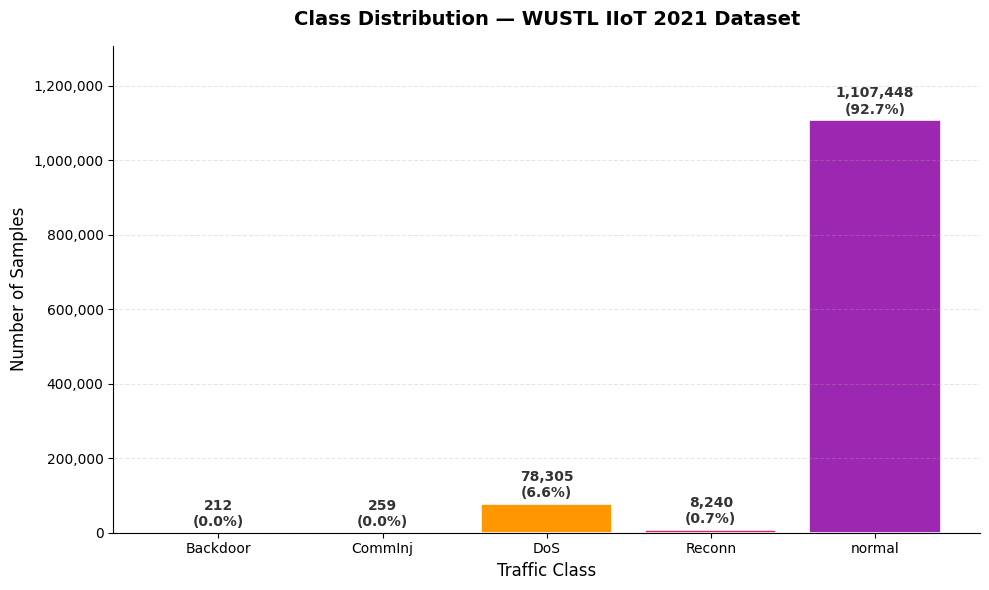

Saved: class_distribution.png


In [9]:
# ======================================
# EVALUATION 1 - CLASS DISTRIBUTION VISUALIZATION
# ======================================
# Shows class imbalance in the dataset with counts and percentages.

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Get class names from the LabelEncoder
class_names = le.classes_
class_counts = y.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0'][:len(class_names)]
bars = ax.bar(class_names, class_counts.values, color=colors, edgecolor='white', linewidth=1.2)

# Add count + percentage labels on each bar
total = class_counts.sum()
for bar, count in zip(bars, class_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.008,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')

ax.set_title('Class Distribution — WUSTL IIoT 2021 Dataset', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Traffic Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, class_counts.max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

In [10]:
# ======================================
# EVALUATION 2 - DETAILED PERFORMANCE METRICS TABLE
# ======================================
# Presents class-wise precision, recall, F1 + macro/weighted aggregates.

from sklearn.metrics import (classification_report, accuracy_score,
                             precision_score, recall_score, f1_score)
import pandas as pd

class_names = le.classes_

# --- Overall Metrics ---
accuracy  = accuracy_score(y_test, preds)
macro_f1  = f1_score(y_test, preds, average='macro')
weighted_f1 = f1_score(y_test, preds, average='weighted')
macro_prec = precision_score(y_test, preds, average='macro')
macro_rec  = recall_score(y_test, preds, average='macro')

print("=" * 55)
print("         OVERALL PERFORMANCE SUMMARY")
print("=" * 55)
overall = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall',
               'Macro F1-Score', 'Weighted F1-Score'],
    'Score': [accuracy, macro_prec, macro_rec, macro_f1, weighted_f1]
})
overall['Score'] = overall['Score'].map(lambda x: f"{x:.4f}")
print(overall.to_string(index=False))
print()

# --- Class-wise Metrics ---
print("=" * 55)
print("         CLASS-WISE PERFORMANCE")
print("=" * 55)
report_dict = classification_report(y_test, preds, target_names=class_names, output_dict=True)

rows = []
for cls in class_names:
    r = report_dict[cls]
    rows.append({
        'Class': cls,
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1-Score': f"{r['f1-score']:.4f}",
        'Support': int(r['support'])
    })

class_df = pd.DataFrame(rows)
print(class_df.to_string(index=False))
print()

         OVERALL PERFORMANCE SUMMARY
           Metric  Score
         Accuracy 1.0000
  Macro Precision 1.0000
     Macro Recall 0.9856
   Macro F1-Score 0.9925
Weighted F1-Score 1.0000

         CLASS-WISE PERFORMANCE
   Class Precision Recall F1-Score  Support
Backdoor    1.0000 0.9286   0.9630       42
 CommInj    1.0000 1.0000   1.0000       52
     DoS    1.0000 1.0000   1.0000    15661
  Reconn    1.0000 0.9994   0.9997     1648
  normal    1.0000 1.0000   1.0000   221490



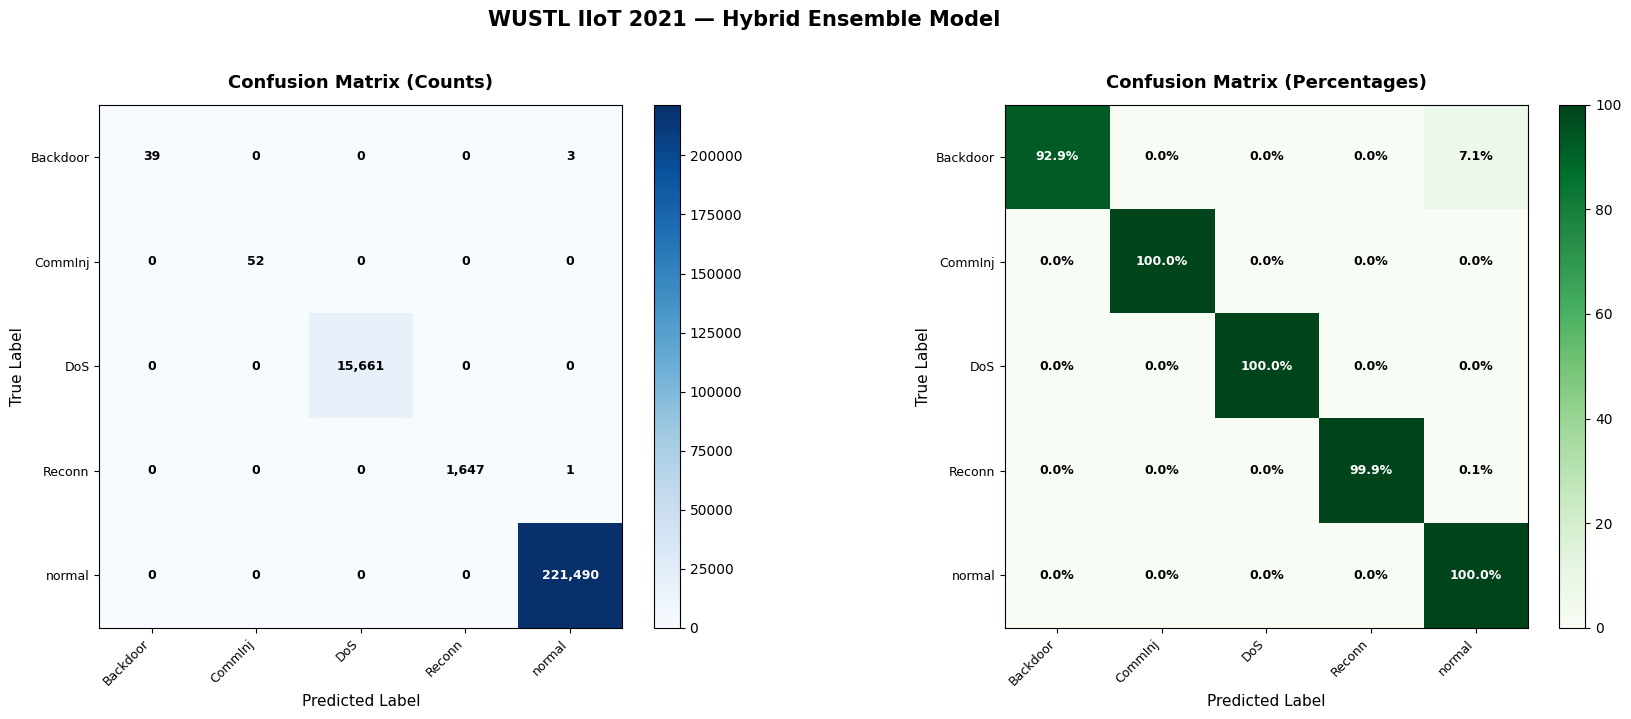

Saved: confusion_matrix.png


In [11]:
# ======================================
# EVALUATION 3 - CONFUSION MATRIX
# ======================================
# Professional confusion matrix with percentage annotations.

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

class_names = le.classes_
cm = confusion_matrix(y_test, preds)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: Count Matrix ---
im0 = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold', pad=12)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        axes[0].text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                     fontsize=9, color=color, fontweight='bold')

axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(class_names, fontsize=9)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# --- Right: Percentage Matrix ---
im1 = axes[1].imshow(cm_pct, interpolation='nearest', cmap='Greens', vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=13, fontweight='bold', pad=12)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        color = 'white' if cm_pct[i, j] > 50 else 'black'
        axes[1].text(j, i, f'{cm_pct[i, j]:.1f}%', ha='center', va='center',
                     fontsize=9, color=color, fontweight='bold')

axes[1].set_xticks(range(len(class_names)))
axes[1].set_yticks(range(len(class_names)))
axes[1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(class_names, fontsize=9)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('WUSTL IIoT 2021 — Hybrid Ensemble Model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

In [12]:
# ======================================
# EVALUATION 4 - 5-FOLD CROSS VALIDATION
# ======================================
# Uses fresh clones of the model to avoid overwriting the trained ensemble.
# Applies the same SHAP-based feature weighting before each fold.

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone
import numpy as np
import time

print("Running 5-Fold Stratified Cross-Validation...")
print("(This trains fresh model copies per fold - does NOT touch the main model)")
print()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Apply feature weighting to entire dataset
X_weighted = X * weights_vector

fold_accuracies = []
fold_macro_f1s = []

t_start = time.time()

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_weighted, y), 1):
    t0 = time.time()
    
    X_fold_train = X_weighted.iloc[train_idx]
    y_fold_train = y.iloc[train_idx]
    X_fold_val   = X_weighted.iloc[val_idx]
    y_fold_val   = y.iloc[val_idx]
    
    # Clone fresh models (no GPU for speed in CV — these are lightweight)
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
    from sklearn.ensemble import VotingClassifier
    
    num_classes = y.nunique()
    
    xgb_cv = XGBClassifier(
        n_estimators=300, objective="multi:softmax", num_class=num_classes,
        eval_metric="mlogloss", tree_method="hist", device="cuda", random_state=42
    )
    lgb_cv = LGBMClassifier(
        n_estimators=300, objective="multiclass", num_class=num_classes,
        device="cpu", n_jobs=-1, random_state=42
    )
    cat_cv = CatBoostClassifier(
        n_estimators=300, loss_function="MultiClass",
        task_type="GPU", devices="0", verbose=0, random_state=42
    )
    
    cv_model = VotingClassifier(
        estimators=[('xgb', xgb_cv), ('lgb', lgb_cv), ('cat', cat_cv)],
        voting='soft'
    )
    
    cv_model.fit(X_fold_train, y_fold_train)
    cv_preds = cv_model.predict(X_fold_val)
    
    acc = accuracy_score(y_fold_val, cv_preds)
    mf1 = f1_score(y_fold_val, cv_preds, average='macro')
    
    fold_accuracies.append(acc)
    fold_macro_f1s.append(mf1)
    
    print(f"  Fold {fold_idx}/5  |  Accuracy: {acc:.4f}  |  Macro F1: {mf1:.4f}  |  Time: {time.time()-t0:.1f}s")

print(f"\nTotal CV Time: {time.time()-t_start:.1f}s")
print()
print("=" * 55)
print("       5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 55)
print(f"  Accuracy   :  {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}")
print(f"  Macro F1   :  {np.mean(fold_macro_f1s):.4f} +/- {np.std(fold_macro_f1s):.4f}")
print("=" * 55)

Running 5-Fold Stratified Cross-Validation...
(This trains fresh model copies per fold - does NOT touch the main model)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6981
[LightGBM] [Info] Number of data points in the train set: 955571, number of used features: 37
[LightGBM] [Info] Start training from score -8.634266
[LightGBM] [Info] Start training from score -8.437346
[LightGBM] [Info] Start training from score -2.724841
[LightGBM] [Info] Start training from score -4.976452
[LightGBM] [Info] Start training from score -0.075640
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

In [13]:
# ======================================
# EVALUATION 5 - BASELINE MODEL COMPARISON
# ======================================
# Trains lightweight baselines on the SAME weighted features for fair comparison.
# Does NOT modify the main trained model.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import time

print("Training Baseline Models for Comparison...")
print("(Using same SHAP-weighted features: X_train_w / X_test_w)")
print()

baselines = {}

# --- 1. Logistic Regression ---
print("  [1/3] Logistic Regression...")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial',
                        n_jobs=-1, random_state=42)
lr.fit(X_train_w, y_train)
lr_preds = lr.predict(X_test_w)
baselines['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, lr_preds),
    'Macro F1': f1_score(y_test, lr_preds, average='macro'),
    'Weighted F1': f1_score(y_test, lr_preds, average='weighted'),
    'Time (s)': round(time.time() - t0, 1)
}
print(f"    Done in {baselines['Logistic Regression']['Time (s)']}s")

# --- 2. Random Forest ---
print("  [2/3] Random Forest...")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
rf.fit(X_train_w, y_train)
rf_preds = rf.predict(X_test_w)
baselines['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, rf_preds),
    'Macro F1': f1_score(y_test, rf_preds, average='macro'),
    'Weighted F1': f1_score(y_test, rf_preds, average='weighted'),
    'Time (s)': round(time.time() - t0, 1)
}
print(f"    Done in {baselines['Random Forest']['Time (s)']}s")

# --- 3. Single XGBoost ---
print("  [3/3] Single XGBoost...")
t0 = time.time()
xgb_single = XGBClassifier(
    n_estimators=300, objective="multi:softmax", num_class=y.nunique(),
    eval_metric="mlogloss", tree_method="hist", device="cuda", random_state=42
)
xgb_single.fit(X_train_w, y_train)
xgb_preds = xgb_single.predict(X_test_w)
baselines['Single XGBoost'] = {
    'Accuracy': accuracy_score(y_test, xgb_preds),
    'Macro F1': f1_score(y_test, xgb_preds, average='macro'),
    'Weighted F1': f1_score(y_test, xgb_preds, average='weighted'),
    'Time (s)': round(time.time() - t0, 1)
}
print(f"    Done in {baselines['Single XGBoost']['Time (s)']}s")

# --- Add Proposed Ensemble ---
baselines['Proposed Ensemble'] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Macro F1': f1_score(y_test, preds, average='macro'),
    'Weighted F1': f1_score(y_test, preds, average='weighted'),
    'Time (s)': '-'
}

# --- Comparison Table ---
print()
print("=" * 70)
print("              MODEL COMPARISON TABLE")
print("=" * 70)
comp_df = pd.DataFrame(baselines).T
comp_df.index.name = 'Model'
for col in ['Accuracy', 'Macro F1', 'Weighted F1']:
    comp_df[col] = comp_df[col].map(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
print(comp_df.to_string())
print()

Training Baseline Models for Comparison...
(Using same SHAP-weighted features: X_train_w / X_test_w)

  [1/3] Logistic Regression...
    Done in 190.8s
  [2/3] Random Forest...
    Done in 81.0s
  [3/3] Single XGBoost...
    Done in 8.9s

              MODEL COMPARISON TABLE
                    Accuracy Macro F1 Weighted F1 Time (s)
Model                                                     
Logistic Regression   0.9462   0.4310      0.9334    190.8
Random Forest         1.0000   0.9857      1.0000     81.0
Single XGBoost        1.0000   0.9818      1.0000      8.9
Proposed Ensemble     1.0000   0.9925      1.0000        -



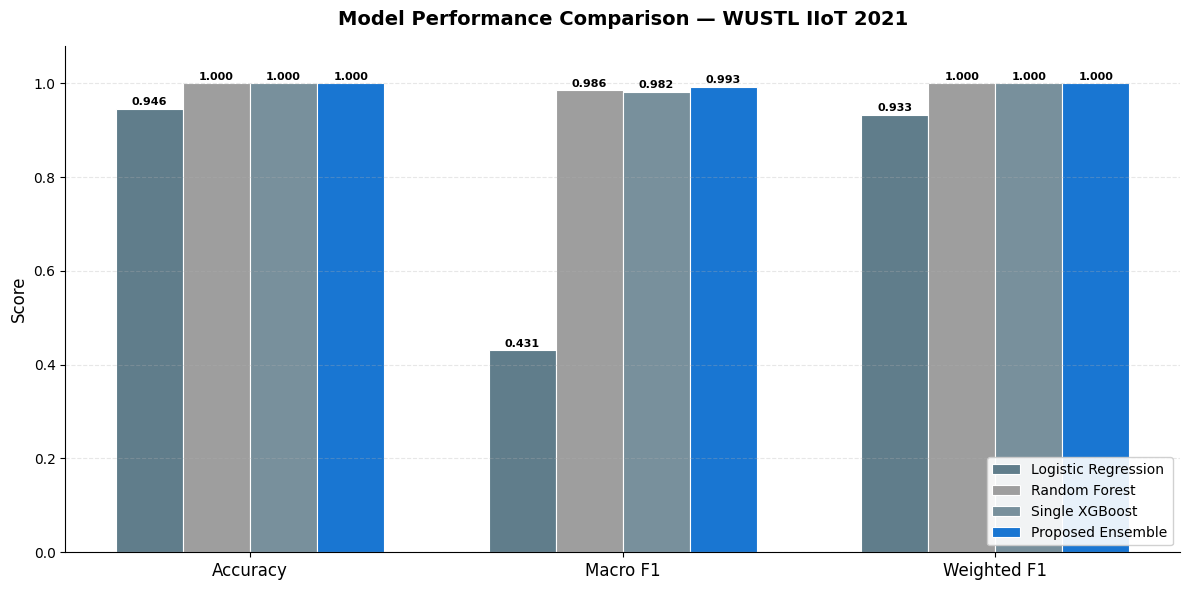

Saved: model_comparison.png

  ALL EVALUATION BLOCKS COMPLETED SUCCESSFULLY


In [14]:
# ======================================
# EVALUATION 6 - COMPARISON BAR CHART
# ======================================
# Visual comparison of all models.

import matplotlib.pyplot as plt
import numpy as np

model_names = list(baselines.keys())
metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
colors = ['#607D8B', '#9E9E9E', '#78909C', '#1976D2']  # Grey baselines, blue ensemble

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.18
offsets = np.linspace(-(len(model_names)-1)*width/2, (len(model_names)-1)*width/2, len(model_names))

for idx, (model, offset) in enumerate(zip(model_names, offsets)):
    vals = [float(baselines[model][m]) for m in metrics]
    bars = ax.bar(x + offset, vals, width, label=model, color=colors[idx],
                  edgecolor='white', linewidth=0.8)
    # Add value labels
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — WUSTL IIoT 2021', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 1.08)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

print("\n" + "=" * 55)
print("  ALL EVALUATION BLOCKS COMPLETED SUCCESSFULLY")
print("=" * 55)